In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import sys
import os
import joblib
from tqdm import tqdm
import networkx as nx

from ou_model import forward, backward, score, classify, theoretical_ts
from plotting import plot_speciation_3d

from construct_graph import construct_graph # this comes from the SASNE repo
from adaptive_knn import AdaptiveKNNGraph # comes from graph-theory repo

### Toy example - small d and n

In [2]:
torch.manual_seed(123)
d = 2            # Dimension
nsamples_small_n = 6     # Number of trajectories
T_max = 10.0
dt = 0.01
times = np.arange(T_max, 0, -dt)

mu_star, std = torch.tensor([4.0, 4.0]), 1.0

In [3]:
small_n_path_history = []
# Start with pure random noise at t=T 
small_n_x_current = torch.randn(d, nsamples_small_n) 

for t in tqdm(times):
    small_n_path_history.append(small_n_x_current.T.clone().numpy()) 
    small_n_x_current, _ = backward(small_n_x_current, t, dt, mu_star, std)
    
small_n_path_history = np.array(small_n_path_history)

100%|███████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 23541.42it/s]


Since we can solve the score function analytically, we just need to sample using he backward process
The particles' starting point is the same, the trajectories will remain tangled until the end of the backward process. 
Once speciating takes place, the path commits to a class until the end of the reverse process.
It is at this point that the reverse process starts producing features of the same class. Since we know the exact form of the score function there is not a collapse time.

In [4]:
Lambda = np.linalg.norm(mu_star)**2 + std**2
t_s = np.log(Lambda) / 2
t_s_idx = next(idx for idx, t in enumerate(times) if round(t, 2) == round(t_s, 2))
print(t_s)

1.7482537641375833


#### Visualize trajectories

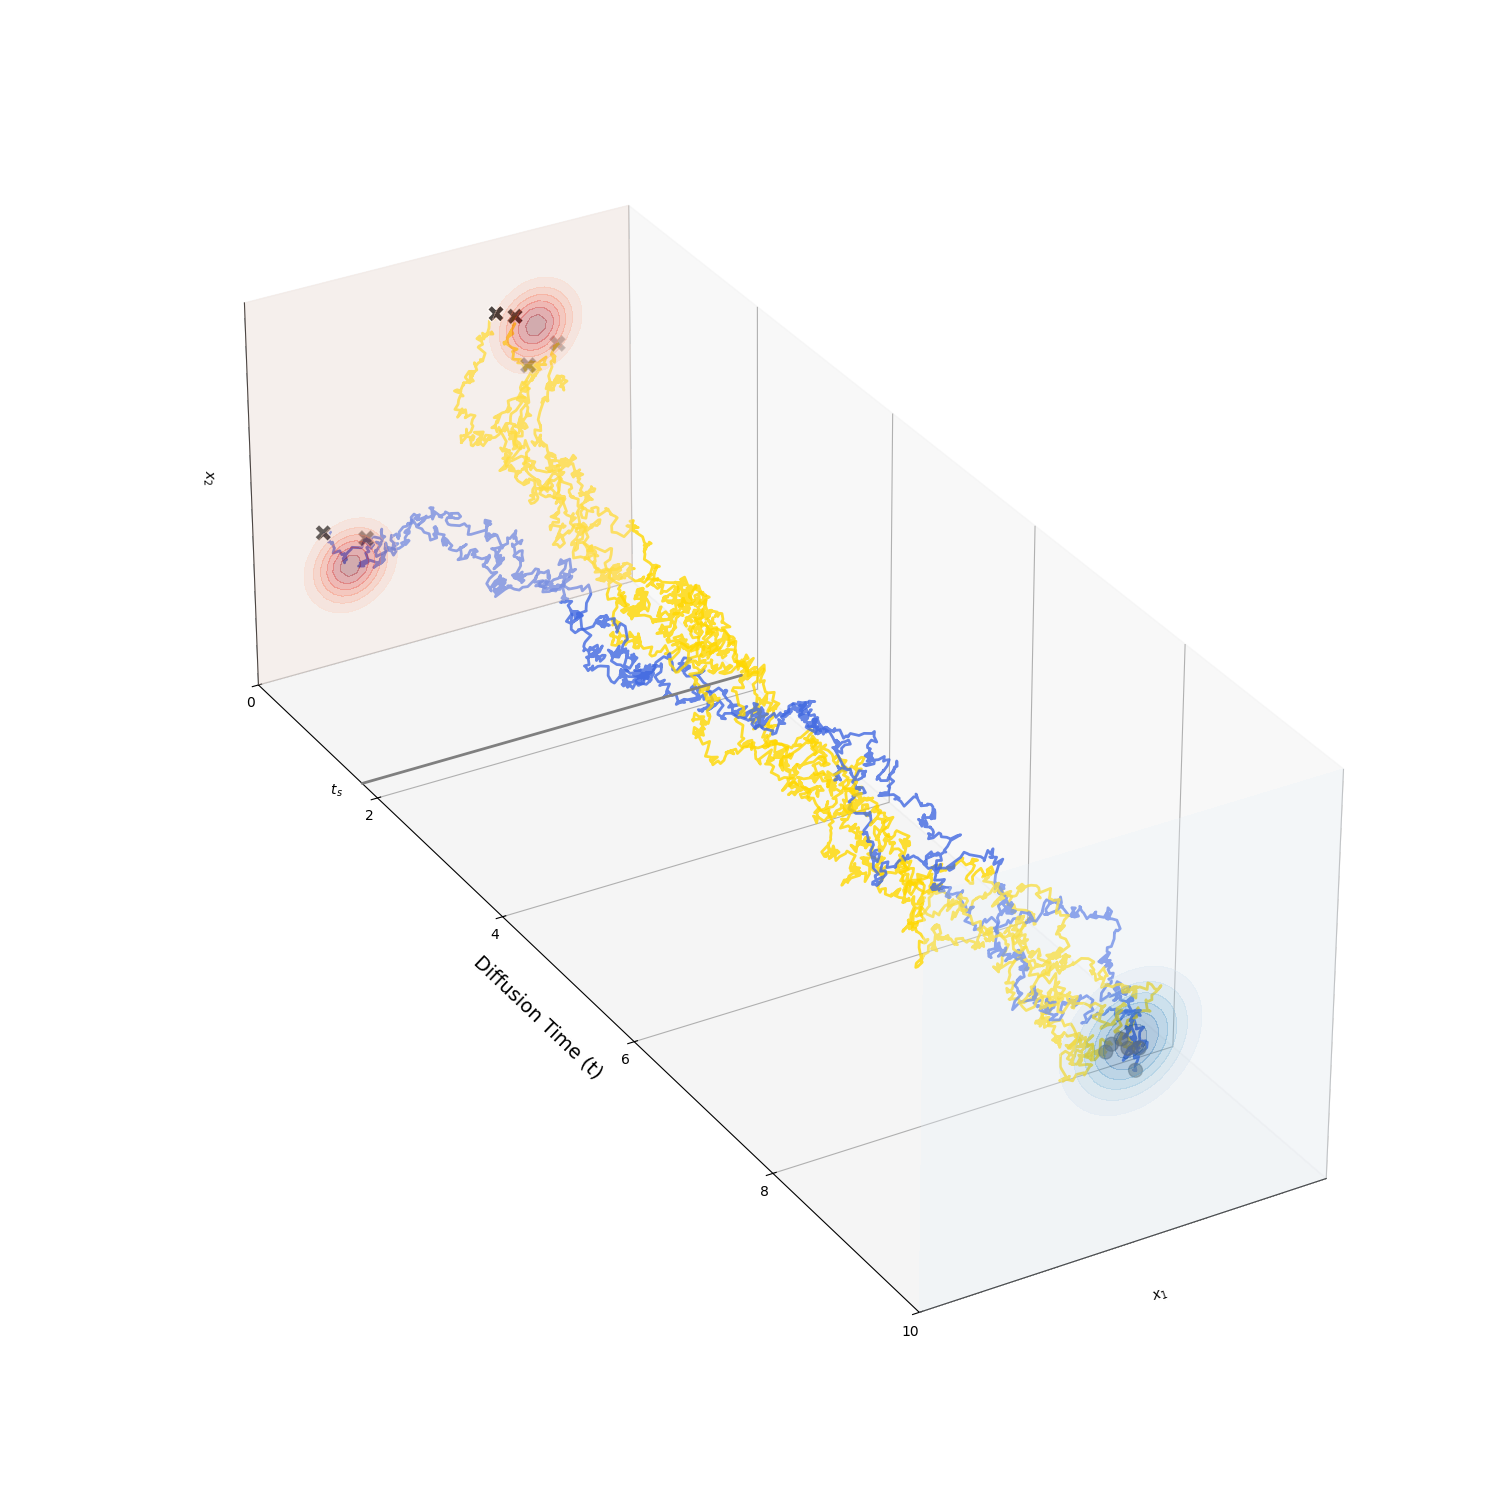

In [5]:
plot_speciation_3d(path_history=small_n_path_history, times=times, mu_star=mu_star, std=std, nsamples=nsamples_small_n, t_s=t_s, t_c=None)

### Knn graph from data at different time steps

In [7]:
loaded_data = joblib.load("../data/D2_MU_4_N1000_100ts/D2_N1000.jbl")
large_n_path_history = loaded_data["history"]

tsm, ts_idx = theoretical_ts(mu_star, std, times)
X_T = torch.as_tensor(large_n_path_history[-1], dtype=mu_star.dtype).T
node_labels = classify(X_T, mu_star)
colors = node_labels.numpy().flatten()
W_list_knn = [AdaptiveKNNGraph(large_n_path_history[idx]).compute_W() for idx in [0, ts_idx, -1]]

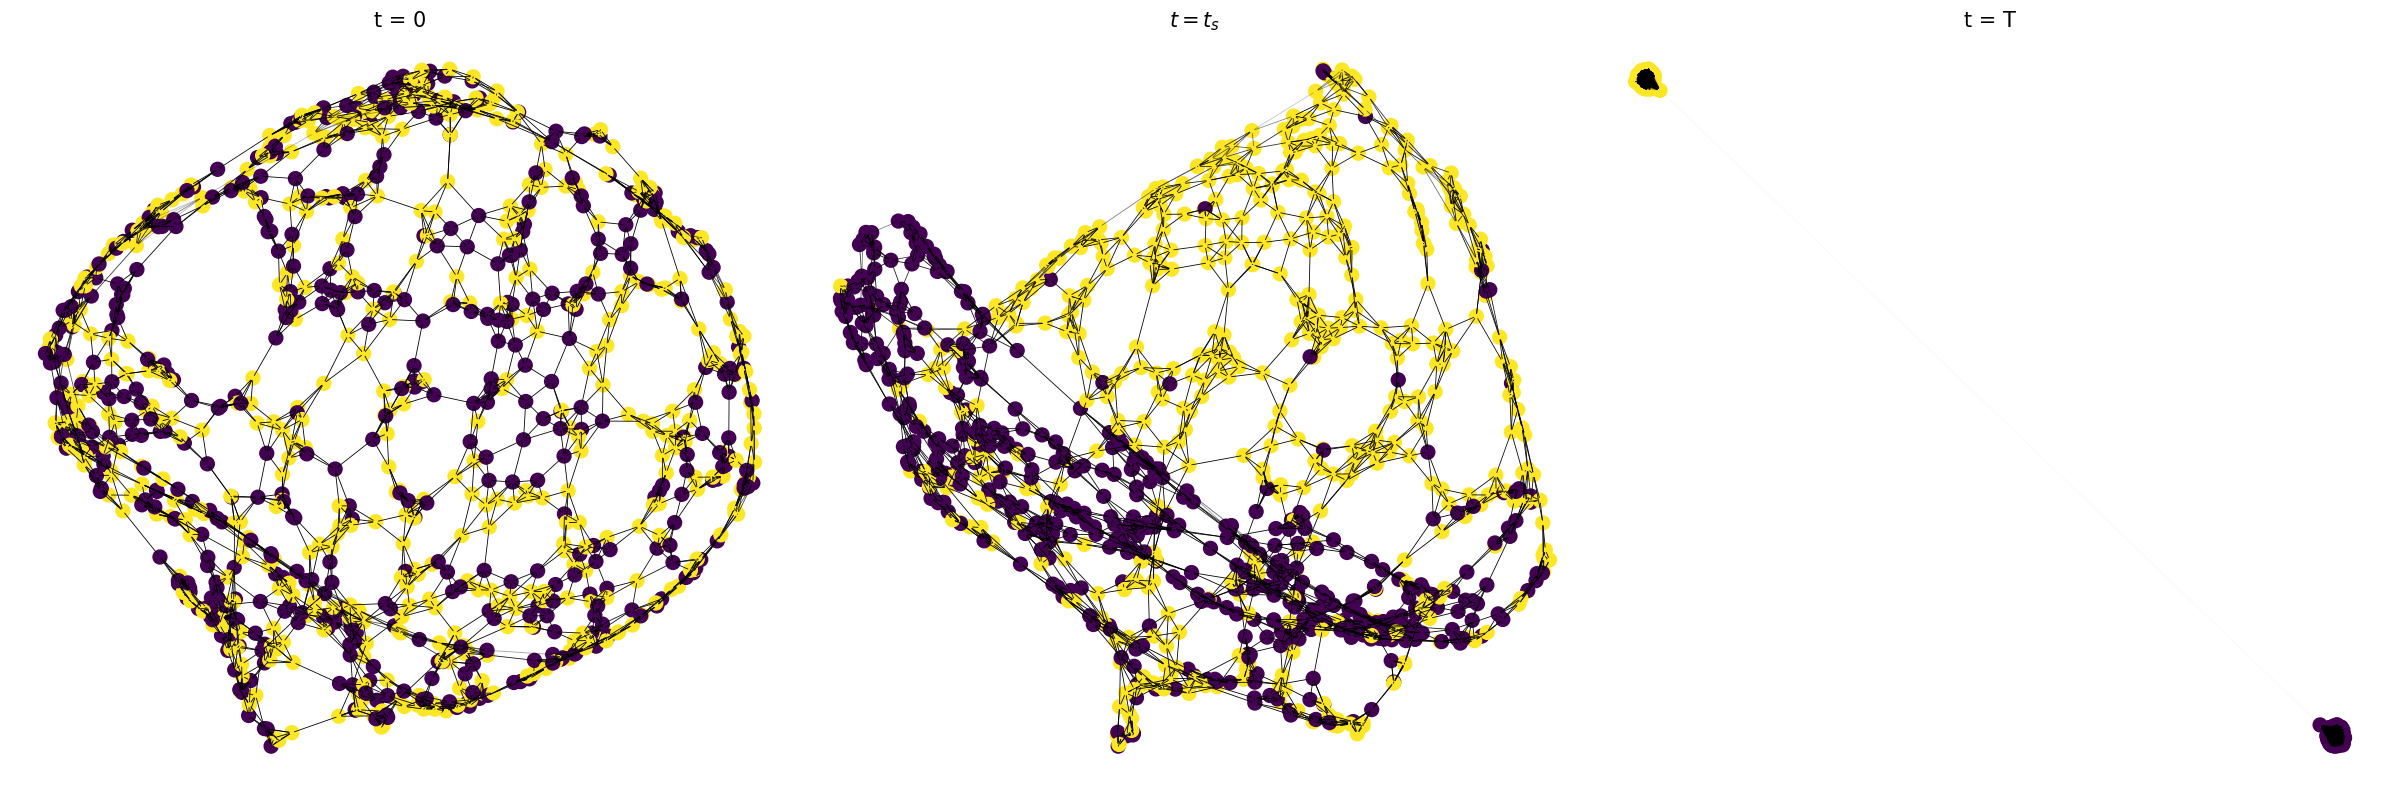

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
titles = ["t = 0", "$t = t_s$", "t = T"]
for i, W in enumerate(W_list_knn):
    G = nx.from_numpy_array(W)
    pos = nx.spring_layout(G, seed=42, k=0.15) 
    ax = axes[i]
    nx.draw_networkx_nodes(G, pos, node_size=100, node_color=colors, ax=ax)
    edges = G.edges(data=True)
    for u, v, d in edges:
        ax.annotate("", xy=pos[v], xycoords='data', xytext=pos[u], textcoords='data',
                    arrowprops=dict(arrowstyle="-", color="black", alpha=min(max(d['weight'], 0), 1),lw=0.6))
    ax.set_title(titles[i], fontsize=15)
    ax.axis('off')
plt.tight_layout()
plt.show()